#### Customer Segmentation using Hierarhical Clustering or Agglomerative Clustering


#####   1.  Problem Statement


A Shoping company wants to understand various customer groups based on Annual Income and Spending scores.

It uses the Hierarchical clustering to divide the customers into various groups.


#### Hierarchical Clustering (Agglomerative Clustering)

(i)     It is an unsupervised machine learning algorithm.

(ii)    It is a part of Clustering technique.

(iii)   It helps in building the clusters from the dataset in a tree structured manner.


#### Types of Hierarchical Clustering

(i)     Agglomerative Clustering

(ii)    Divisive Clustering


1.  Agglomerative Clustering ============>

    (a.)    It follows the bottom up approach and builds all the clusters in a tree structure form.


#### Terminologies:

1.  Dendogram ============>  It is a tree based structure that helps in analyzing and visualizing the cluster merging.

2.  Linkage   ============>  

    (a.)    It is used to calculate the distance between the data points.  

    (b.)    It determines which clusters should merge together.

    (c.)    It even determines at what distance the clusters should the clusters merge together.

    (d.)    It is used to perform the hierarchical clustering.


#### Step 1: Import all the necessary libraries

In [430]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection     import train_test_split
from    sklearn.preprocessing       import StandardScaler
from    sklearn.cluster             import AgglomerativeClustering
from    scipy.cluster.hierarchy     import dendrogram, linkage

#### Step 2: Load the dataset

In [431]:
#### Load the dataset

df = pd.read_csv("Mall_Customers_dataset.csv")

In [432]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### OBSERVATIONS:

1.  The above dataset explains all the details of the customer along with their "Annual Income" and their "Spending Score".

#### Step 3: Perform the Data Exploration

In [433]:
#### get the first five rows of the dataset

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [434]:
#### get the last five rows of the dataset

df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [435]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 200


In [436]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (200, 5)


In [437]:
#### get the columns used in the dataset

print(df.columns)

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')


In [438]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [439]:
#### get the descriptive summary statistics about the numerical columns used in the dataset

df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### OBSERVATIONS:

1.  The above summary explains about the descriptive summary statistics about each numerical column used in the dataset.

In [440]:
#### get the descriptive summary statistics about the categorical columns used in the dataset

df.describe(include='object')

,Genre
count,200
unique,2
top,Female
freq,112


#### OBSERVATIONS:

1.  The above summary explains about the descriptive summary statistics about each categorical column used in the dataset.

#### Step 4: Perform the Data Cleaning and Feature Engineering

In [441]:
#### To rename the column names with their proper names

df.rename(columns={"Genre"                   :   "Gender"             ,
                    "Annual Income (k$)"     :   "Annual_Income"      ,
                    "Spending Score (1-100)" :   "Spending_Score"},
                    inplace=True)

In [442]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### OBSERVATIONS:

1.  All the column names have been renamed with their proper names.

In [443]:
#### To remove the un necessary column "CustomerID" from the dataset

df.drop(columns="CustomerID",axis=1,inplace=True)

In [444]:
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


#### OBSERVATIONS:

1.  The CustomerID column has been removed from the dataset.

In [445]:
#### To convert all the categorical columns of 'Gender' into the numerical values

from  sklearn.preprocessing import LabelEncoder

#### create an object for Label Encoder

label = LabelEncoder()

#### using the object for Label Encoder, transform the inputs

df['Gender'] = label.fit_transform(df['Gender'])

In [446]:
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


#### OBSERVATIONS:

1.  All the categorical values of Gender column have been converted into their numerical values.

In [447]:
#### To check for all the NULL records in the dataset

df.isnull().sum()

Gender            0
Age               0
Annual_Income     0
Spending_Score    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [448]:
#### To check for any duplicate records in the dataset

df[df.duplicated()]

,Gender,Age,Annual_Income,Spending_Score


#### OBSERVATIONS:

1.  There are no duplicate records used in the dataset.

#### Step 5: Perform Exploratory Data Analysis

In [449]:
#### To get the correlation for all the numerical columns in the dataset

df.corr()

,Gender,Age,Annual_Income,Spending_Score
Gender,1.000000,0.060867,0.056410,-0.058109
Age,0.060867,1.000000,-0.012398,-0.327227
Annual_Income,0.056410,-0.012398,1.000000,0.009903
Spending_Score,-0.058109,-0.327227,0.009903,1.000000


#### OBSERVATIONS:

1.  The above table depicts about the correlation between all the numerical columns used in the dataset.

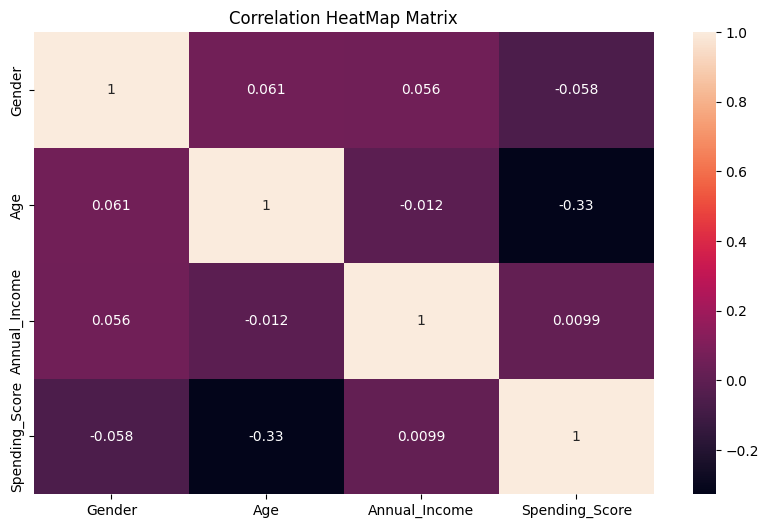

In [450]:
#### To get the graphical representation for the correlation for all the numerical columns in the dataset

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(),annot=True)
plt.title("Correlation HeatMap Matrix")
plt.show()

#### OBSERVATIONS:

1.  The above graphical representation depicts about the numerical correlation for all the column used in the dataset.

2.  The correlation between the 'Gender' and 'Age' is very high.

3.  The correlation between the 'Age' and 'Spending Score' is very low.

#### Step 6: Select Important Features

In [451]:
#### Select all the important features

X = df[['Annual_Income','Spending_Score']]

In [452]:
X

,Annual_Income,Spending_Score
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


#### OBSERVATIONS:

1.  The features that were selected for performing the clustering operation in the dataset is 

    (a.)    Annual_Income

    (b.)    Spending_Score

#### Step 7: Perform the Feature Scaling on the selected features

In [453]:
from sklearn.preprocessing import StandardScaler

##### create an object for StandardScaler

sc = StandardScaler()

#### using the object for Standard Scaler, transform the inputs

X_scaled = sc.fit_transform(X)

In [454]:
X_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

#### OBSERVATIONS:

1.  Feature scaling standardizes all features to zero mean and unit variance.

2.  This prevents one feature from dominating due to larger scale.

#### Step 8: Perform Dendrogram to determine the optimal number of clusters

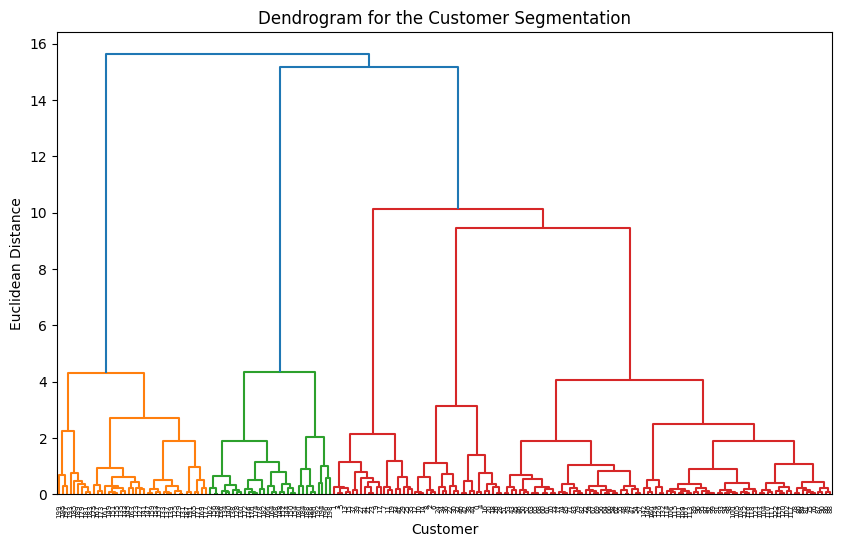

In [455]:
plt.figure(figsize=(10,6))

#### plot the dendrogram to visualize the cluster mapping
dendrogram(
    linkage(X_scaled,method='ward')
)

#### give the title of the graph
plt.title("Dendrogram for the Customer Segmentation")

#### plot the x-axis of the graph
plt.xlabel("Customer")

#### plot the y-axis of the graph
plt.ylabel("Euclidean Distance")

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  dendrogram is a tree like structure that helps in analyzing and visualizing the cluster merging.

2.  linkage is a metric that is used to compute the distance between the data points.

    (a.)    method = 'ward' ===========>  minimizes the variances between the clusters.

3.  Plotting the dendrogram helps in determining the total number of clusters formed in the dataset.

4.  The longest vertical line ranges rom 10 till 15.

5.  So a horizontal line passes through the vertical lines and makes three vertical cuts while crossing through three vertical lines.

6.  So the total number of clusters formed are 3.

7.  There are three groups of clusters formed. They are as follows :-----

    (a.)    Orange left ==================>

        (i) Customer with low annual  income and low spending score.

    (b.)    Green Middle =================>

        (i) Customer with medium annual income and medium spending score.

    (c.)    Red Right  ====================>

        (i) Customer with high annual income and high spending score. 

#### Step 9:  Perform Agglomerative Clustering

In [456]:
from sklearn.cluster  import  AgglomerativeClustering

#### create an object for Agglomerative Clustering

agg = AgglomerativeClustering(
    n_clusters      =       3               ,
    metric          =       'euclidean'     ,
    linkage         =        'ward'       
)

#### OBSERVATIONS:

1.  The object for Agglomerative Clustering has been created using the following parameters :------

    (a.)    n_clusters = 3 ===========> Total three clusters are considered 

    (b.)    metric     = euclidean =====>   Euclidean distance is used to compute the distance between the data points

    (c.)    linkage    = 'ward'  ========>  It minimizes the variance between the clusters and makes sure all the data points are closed together and dense clusters are formed.

#### Step 10: Train and Predict the Agglomerative Clustering to determine the labels

In [457]:
#### using the object of AgglomerativeClustering, train and predict the model

Y_pred = agg.fit_predict(X_scaled)

In [458]:
Y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 1, 2, 1,
       0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 0, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1,
       2, 1])

#### OBSERVATIONS:

1.  The object for Agglomerative Clustering is formed.

2.  Using the object for Agglomerative Clustering, the model is trained with the input data.

3.  Then the labels are predicted from the input data.

4.  The labels that are formed are as follows:----

    (a.) Label 0 ==============>  Customer with low annual income and low spending score

    (b.) Label 1 ==============>  Customer with medium annual income and medium spending score

    (c.) Label 2 ==============>  Customer with high annual income and high spending score

#### Step 11: Add the cluster labels to the dataset

In [459]:
df['Labels'] = Y_pred

In [460]:
df.head()

,Gender,Age,Annual_Income,Spending_Score,Labels
0,1,19,15,39,0
1,1,21,15,81,0
2,0,20,16,6,0
3,0,23,16,77,0
4,0,31,17,40,0


#### OBSERVATIONS:

1.  Here all the cluster labels have been added to the dataset.

#### Step 12: Visualize the Clusters

In [461]:
df['Labels'].value_counts()

Labels
0    129
1     39
2     32
Name: count, dtype: int64

#### OBSERVATIONS:

1.  The total number of clusters formed in the dataset is 3

    (a.)    Cluster 0

    (b.)    Cluster 1

    (c.)    Cluster 2

2.  As three clusters are formed, so plotting of three clusters must be done.

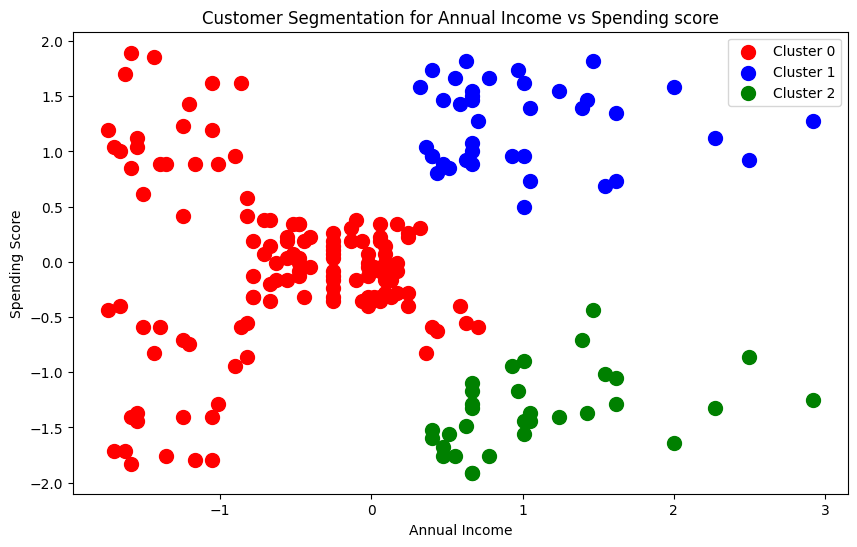

In [462]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_scaled[Y_pred == 0,0]                  ,
    X_scaled[Y_pred == 0,1]                  ,
    s                =          100          ,
    c                =          'red'        ,
    label            =          'Cluster 0'         
)



plt.scatter(
    X_scaled[Y_pred == 1,0]                  ,
    X_scaled[Y_pred == 1,1]                  ,
    s                =          100          ,
    c                =          'blue'       ,
    label            =          'Cluster 1'         
)


plt.scatter(
    X_scaled[Y_pred == 2,0]                  ,
    X_scaled[Y_pred == 2,1]                  ,
    s                =          100          ,
    c                =          'green'      ,
    label            =          'Cluster 2'         
)


##### get the title of the graph
plt.title("Customer Segmentation for Annual Income vs Spending score")

#### get the x axis of the graph
plt.xlabel("Annual Income")

#### get the y axis of the graph
plt.ylabel("Spending Score")

#### get the legend of the graph
plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  Three clusters are formed from the dataset using Agglomerative Clustering

    (a.)    Cluster 1 ==============>  It indicates the customers with low annual income and high spending score

    (b.)    Cluster 2 ==============>  It indicates the customers with medium annual income and medium spending score

    (c.)    Cluster 3 ==============>  It indicates the customers with high annual income and low spending score.